# 🧬 BioCascade: Feature Engineering & Cascade Interactions

## Notebook Overview

**Purpose:** Transform raw biomarkers into clinically meaningful features that capture multi-system cascade dysfunction in HFpEF-like phenotypes.

**Input:** Validated patient data from Notebook 01  
**Output:** Enhanced feature matrix with ~50 engineered features  
**Key Innovation:** Cascade interaction features (vascular-metabolic, metabolic-renal)

---

## Feature Engineering Philosophy

### Why Engineer Features?

**Raw biomarkers provide incomplete information:**
- Systolic BP = 140 mmHg → Is this concerning?
- Depends on: Age, kidney function, glucose control, obesity

**Engineered features capture context:**
- **Ratios** reveal relative dysfunction (e.g., TG/HDL ratio)
- **Interactions** capture cascade effects (e.g., BP × HbA1c)
- **Calculated scores** integrate multiple systems (e.g., eGFR, MetS score)

---

## Feature Categories I will Create

### 1. **Metabolic Syndrome Markers** 🍔
- TG/HDL ratio (lipid dysfunction)
- Waist/height ratio (central obesity)
- Non-HDL cholesterol
- Total/HDL ratio
- Metabolic Syndrome Score (ATP III criteria)

### 2. **Renal Function Calculations** 🫘
- eGFR (CKD-EPI equation)
- BUN/Creatinine ratio
- Markers of kidney stress

### 3. **Blood Pressure Derivatives** 🫀
- Pulse pressure (arterial stiffness)
- Mean arterial pressure
- Pressure-related stress

### 4. **Inflammatory Markers** 🔥
- Neutrophil/Lymphocyte ratio
- Log-transformed hsCRP
- Inflammatory burden

### 5. **CASCADE INTERACTIONS** ⚡ (My Innovation!)
- **Vascular-Metabolic Load:** BP × Glucose
- **Metabolic-Renal Stress:** Glucose × (1/kidney function)
- Multi-system dysfunction capture

---

## Expected Outcomes

- Expand from ~30 raw features to ~50 total features
- Create interpretable, clinically-grounded features
- Capture non-linear relationships and system interactions
- Enable ML to learn complex pathophysiologic patterns

---

In [25]:
# Data manipulation
import pandas as pd
import numpy as np
import duckdb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [26]:
# Connect to database
db_path = '../data/processed/biocascade.db'
con = duckdb.connect(db_path, read_only=True)

# Load labeled patient data (from labeling.py)
df = con.execute("SELECT * FROM labeled_patients").df()

print(f"✅ Loaded {len(df):,} labeled patients")
print(f"📊 Starting with {len(df.columns)} columns")
print(f"\n🔴 High Risk: {(df['is_high_risk']==1).sum():,} patients")
print(f"🟢 Low Risk:  {(df['is_high_risk']==0).sum():,} patients")

df.head()

✅ Loaded 4,573 labeled patients
📊 Starting with 35 columns

🔴 High Risk: 338 patients
🟢 Low Risk:  4,235 patients


,SEQN,age,gender,race_ethnicity,systolic_bp,diastolic_bp,bmi,waist_cm,height_cm,weight_kg,...,wbc_count,lymphocyte_pct,neutrophil_pct,ferritin,serum_iron,bp_flag,a1c_flag,renal_flag,risk_factor_count,is_high_risk
0,93706,18,1,6,112.0,74.0,21.5,79.3,175.7,66.3,...,6.1,24.6,61.4,284.0,164.0,0,0,0,0,0
1,93709,75,2,4,120.0,66.0,38.9,113.0,151.1,88.8,...,7.2,25.8,66.1,129.0,63.0,0,0,1,1,0
2,93711,56,1,6,108.0,68.0,21.3,86.6,170.6,62.1,...,5.0,35.5,53.0,40.6,56.0,0,0,0,0,0
3,93712,18,1,1,112.0,68.0,19.7,72.0,172.8,58.9,...,7.1,30.6,59.8,74.1,225.0,0,0,0,0,0
4,93713,67,1,3,104.0,70.0,23.5,99.7,178.6,74.9,...,8.3,34.4,54.7,238.0,74.0,0,0,0,0,0


## 🧮 Feature Engineering Strategy

I will create features in **five categories**, each grounded in cardiovascular pathophysiology:

### Category 1: Metabolic Syndrome Markers
Captures lipid and obesity dysfunction characteristic of HFpEF.

### Category 2: Renal Function
Proper kidney assessment requires age/gender adjustment (not just raw creatinine).

### Category 3: Blood Pressure Derivatives  
Pulse pressure reflects arterial stiffness; MAP reflects overall perfusion.

### Category 4: Inflammatory Markers
Chronic inflammation drives HFpEF progression.

### Category 5: Cascade Interactions (★ MY INNOVATION)
Captures how dysfunction in one system amplifies problems in another.

---

Let's begin! 🚀

---

In [27]:
print("🍔 CATEGORY 1: Metabolic Syndrome Markers")
print("=" * 70)

# === LIPID RATIOS ===
# TG/HDL ratio is a powerful predictor of insulin resistance and cardiovascular risk
df['tg_hdl_ratio'] = df['triglycerides'] / (df['hdl_cholesterol'] + 0.01)  # +0.01 prevents division by zero
print(f"✅ Created: tg_hdl_ratio (Triglycerides / HDL)")
print(f"   Clinical threshold: >3.0 indicates metabolic syndrome")
print(f"   Our mean: {df['tg_hdl_ratio'].mean():.2f}")

# Total/HDL ratio (another atherogenic index)
df['total_hdl_ratio'] = df['total_cholesterol'] / (df['hdl_cholesterol'] + 0.01)
print(f"\n✅ Created: total_hdl_ratio (Total Cholesterol / HDL)")
print(f"   Clinical threshold: >5.0 indicates increased cardiovascular risk")
print(f"   Our mean: {df['total_hdl_ratio'].mean():.2f}")

# Non-HDL cholesterol (all atherogenic lipids)
df['non_hdl'] = df['total_cholesterol'] - df['hdl_cholesterol']
print(f"\n✅ Created: non_hdl (Total - HDL Cholesterol)")
print(f"   Target: <130 mg/dL for optimal cardiovascular health")
print(f"   Our mean: {df['non_hdl'].mean():.1f} mg/dL")

# === ANTHROPOMETRIC RATIOS ===
# Waist/Height ratio is superior to BMI for predicting metabolic risk
df['waist_height_ratio'] = df['waist_cm'] / (df['height_cm'] + 0.01)
print(f"\n✅ Created: waist_height_ratio (Waist / Height)")
print(f"   Clinical threshold: >0.5 indicates central obesity")
print(f"   Our mean: {df['waist_height_ratio'].mean():.3f}")

# === CARDIOMETABOLIC INDEX ===
# Combines lipid and anthropometric risk
df['cardiometabolic_index'] = df['tg_hdl_ratio'] * df['waist_height_ratio']
print(f"\n✅ Created: cardiometabolic_index (TG/HDL × Waist/Height)")
print(f"   Integrates lipid dysfunction with central obesity")
print(f"   Our mean: {df['cardiometabolic_index'].mean():.3f}")

print(f"\n📊 Category 1 Complete: Created 5 metabolic syndrome features")

🍔 CATEGORY 1: Metabolic Syndrome Markers
✅ Created: tg_hdl_ratio (Triglycerides / HDL)
   Clinical threshold: >3.0 indicates metabolic syndrome
   Our mean: 2.50

✅ Created: total_hdl_ratio (Total Cholesterol / HDL)
   Clinical threshold: >5.0 indicates increased cardiovascular risk
   Our mean: 3.77

✅ Created: non_hdl (Total - HDL Cholesterol)
   Target: <130 mg/dL for optimal cardiovascular health
   Our mean: 133.9 mg/dL

✅ Created: waist_height_ratio (Waist / Height)
   Clinical threshold: >0.5 indicates central obesity
   Our mean: 0.602

✅ Created: cardiometabolic_index (TG/HDL × Waist/Height)
   Integrates lipid dysfunction with central obesity
   Our mean: 1.554

📊 Category 1 Complete: Created 5 metabolic syndrome features


## 💡 Metabolic Syndrome Feature Interpretation

### TG/HDL Ratio (Triglycerides / HDL Cholesterol)
**Why it matters:** Strongly associated with insulin resistance, small dense LDL particles, and cardiovascular events.
- **<2.0:** Optimal metabolic health
- **2.0-3.0:** Borderline
- **>3.0:** Metabolic syndrome pattern
- **>5.0:** Severe lipid dysfunction

### Waist/Height Ratio
**Why it matters:** Superior to BMI for predicting cardiometabolic risk; captures central adiposity (visceral fat).
- **<0.5:** Normal
- **0.5-0.6:** Increased risk
- **>0.6:** Substantially increased risk

### Cardiometabolic Index
**Why it matters:** Integrates TWO metabolic pathways (lipid + obesity) into one marker.
- Captures synergistic risk from multiple systems
- Patients with BOTH dyslipidemia AND central obesity have exponentially higher risk

---

In [28]:
print("🫘 CATEGORY 2: Renal Function Calculations")
print("=" * 70)

# === EGFR (CKD-EPI EQUATION) ===
print("Calculating eGFR using CKD-EPI equation...")
print("This adjusts for: age, sex, race, and creatinine")

def calculate_egfr(row):
    """
    Calculate estimated Glomerular Filtration Rate using CKD-EPI equation.
    
    eGFR is the gold standard for assessing kidney function.
    Raw creatinine alone is insufficient (varies by muscle mass, age, sex).
    
    Normal: >90 mL/min/1.73m²
    Mild dysfunction: 60-89
    Moderate: 30-59
    Severe: 15-29
    Kidney failure: <15
    """
    cr = row['serum_creatinine']
    age = row['age']
    is_female = (row['gender'] == 2)
    
    if pd.isna(cr) or pd.isna(age):
        return np.nan
    
    # CKD-EPI formula parameters
    kappa = 0.7 if is_female else 0.9
    alpha = -0.329 if is_female else -0.411
    female_factor = 1.018 if is_female else 1.0
    
    # Calculate eGFR
    min_ratio = min(cr / kappa, 1.0)
    max_ratio = max(cr / kappa, 1.0)
    
    egfr = 141 * (min_ratio ** alpha) * (max_ratio ** -1.209) * (0.993 ** age) * female_factor
    
    return egfr

df['egfr'] = df.apply(calculate_egfr, axis=1)
print(f"✅ Created: egfr (Estimated Glomerular Filtration Rate)")
print(f"   Mean eGFR: {df['egfr'].mean():.1f} mL/min/1.73m²")
print(f"   % with eGFR <60 (CKD): {(df['egfr'] < 60).sum() / len(df) * 100:.1f}%")

# === BUN/CREATININE RATIO ===
df['bun_cr_ratio'] = df['bun'] / (df['serum_creatinine'] + 0.01)
print(f"\n✅ Created: bun_cr_ratio (BUN / Creatinine)")
print(f"   Differentiates prerenal azotemia from intrinsic kidney disease")
print(f"   Normal: 10-20, High: >20 suggests volume depletion")
print(f"   Our mean: {df['bun_cr_ratio'].mean():.1f}")

print(f"\n📊 Category 2 Complete: Created 2 renal function features")

🫘 CATEGORY 2: Renal Function Calculations
Calculating eGFR using CKD-EPI equation...
This adjusts for: age, sex, race, and creatinine
✅ Created: egfr (Estimated Glomerular Filtration Rate)
   Mean eGFR: 91.4 mL/min/1.73m²
   % with eGFR <60 (CKD): 10.3%

✅ Created: bun_cr_ratio (BUN / Creatinine)
   Differentiates prerenal azotemia from intrinsic kidney disease
   Normal: 10-20, High: >20 suggests volume depletion
   Our mean: 17.2

📊 Category 2 Complete: Created 2 renal function features


## 💡 Renal Function Feature Interpretation

### eGFR (Estimated Glomerular Filtration Rate)
**Why I calculate it:** Raw creatinine is misleading!

**Example:**
- **Patient A:** Creatinine 1.2 mg/dL, Age 75, Female → eGFR = 52 (CKD!)
- **Patient B:** Creatinine 1.2 mg/dL, Age 25, Male → eGFR = 88 (Normal!)

Same creatinine, vastly different kidney function!

**CKD-EPI equation accounts for:**
- Age (kidney function naturally declines)
- Sex (women have less muscle mass → lower creatinine baseline)
- Race (in original formula, though this is being revised)

### BUN/Creatinine Ratio
**Clinical utility:** Distinguishes **where** the kidney problem is.

- **Ratio >20:** Prerenal (volume depletion, heart failure, dehydration)
- **Ratio 10-20:** Normal or intrinsic kidney disease
- **Ratio <10:** Overhydration, liver disease

For HFpEF: Often see elevated BUN/Cr due to **poor cardiac output** → kidney hypoperfusion.

---

In [29]:
print("🫀 CATEGORY 3: Blood Pressure Derivatives")
print("=" * 70)

# === PULSE PRESSURE ===
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
print(f"✅ Created: pulse_pressure (Systolic - Diastolic BP)")
print(f"   Reflects arterial stiffness and vascular aging")
print(f"   Normal: 40-60 mmHg, Elevated: >60 mmHg")
print(f"   Our mean: {df['pulse_pressure'].mean():.1f} mmHg")

# === MEAN ARTERIAL PRESSURE ===
df['mean_arterial_pressure'] = df['diastolic_bp'] + (df['pulse_pressure'] / 3)
print(f"\n✅ Created: mean_arterial_pressure (MAP)")
print(f"   Average pressure during one cardiac cycle")
print(f"   Minimum for organ perfusion: 60 mmHg")
print(f"   Our mean: {df['mean_arterial_pressure'].mean():.1f} mmHg")

print(f"\n📊 Category 3 Complete: Created 2 blood pressure features")

🫀 CATEGORY 3: Blood Pressure Derivatives
✅ Created: pulse_pressure (Systolic - Diastolic BP)
   Reflects arterial stiffness and vascular aging
   Normal: 40-60 mmHg, Elevated: >60 mmHg
   Our mean: 54.2 mmHg

✅ Created: mean_arterial_pressure (MAP)
   Average pressure during one cardiac cycle
   Minimum for organ perfusion: 60 mmHg
   Our mean: 89.7 mmHg

📊 Category 3 Complete: Created 2 blood pressure features


## 💡 Blood Pressure Derivative Interpretation

### Pulse Pressure
**What it measures:** The **difference** between systolic and diastolic BP.

**Why it matters:**
- **Wide pulse pressure (>60 mmHg):** Stiff arteries can't cushion the pressure wave
- Seen in: Aging, atherosclerosis, chronic hypertension
- Predicts: Stroke, heart failure, cardiovascular death

**Pathophysiology in HFpEF:**
- Arterial stiffness → increased afterload → LV hypertrophy → diastolic dysfunction

### Mean Arterial Pressure (MAP)
**What it measures:** Average pressure throughout the cardiac cycle (weighted toward diastole).

**Formula:** MAP = Diastolic + (Pulse Pressure / 3)

**Why it matters:**
- Must be >60-65 mmHg to perfuse organs (brain, kidneys, heart)
- Too high (>100): Excess strain on vasculature
- In HFpEF: Balance between perfusion pressure and LV afterload

--- 

In [30]:
print("🔥 CATEGORY 4: Inflammatory Markers")
print("=" * 70)

# === NEUTROPHIL/LYMPHOCYTE RATIO ===
df['neutrophil_lymphocyte_ratio'] = df['neutrophil_pct'] / (df['lymphocyte_pct'] + 0.01)
print(f"✅ Created: neutrophil_lymphocyte_ratio (NLR)")
print(f"   Marker of systemic inflammation and immune response")
print(f"   Normal: 1-3, Elevated: >3, High inflammation: >5")
print(f"   Our mean: {df['neutrophil_lymphocyte_ratio'].mean():.2f}")

# === LOG-TRANSFORMED HSCRP ===
df['log_hscrp'] = np.log1p(df['hscrp'])
print(f"\n✅ Created: log_hscrp (Log-transformed hsCRP)")
print(f"   hsCRP is highly right-skewed; log transform normalizes distribution")
print(f"   hsCRP >3 mg/L indicates high cardiovascular risk")
print(f"   % with hsCRP >3: {(df['hscrp'] > 3).sum() / len(df) * 100:.1f}%")

print(f"\n📊 Category 4 Complete: Created 2 inflammatory features")

🔥 CATEGORY 4: Inflammatory Markers
✅ Created: neutrophil_lymphocyte_ratio (NLR)
   Marker of systemic inflammation and immune response
   Normal: 1-3, Elevated: >3, High inflammation: >5
   Our mean: 2.09

✅ Created: log_hscrp (Log-transformed hsCRP)
   hsCRP is highly right-skewed; log transform normalizes distribution
   hsCRP >3 mg/L indicates high cardiovascular risk
   % with hsCRP >3: 35.7%

📊 Category 4 Complete: Created 2 inflammatory features


## 💡 Inflammatory Marker Interpretation

### Neutrophil/Lymphocyte Ratio (NLR)
**Why it matters:** Simple, cheap marker of systemic inflammation from routine CBC.

**Clinical thresholds:**
- **<3:** Normal inflammatory state
- **3-5:** Moderate inflammation
- **>5:** Significant inflammatory burden

**In HFpEF:**
- Chronic low-grade inflammation drives endothelial dysfunction
- NLR elevated in metabolic syndrome, diabetes, obesity
- Predicts heart failure hospitalizations and mortality

### hsCRP (High-Sensitivity C-Reactive Protein)
**Why log-transform?**
- Raw hsCRP ranges from 0.1 to 50+ mg/L (500-fold range!)
- Highly right-skewed distribution
- Log transformation normalizes for ML algorithms

**Cardiovascular risk categories:**
- **<1 mg/L:** Low risk
- **1-3 mg/L:** Average risk
- **>3 mg/L:** High risk
- **>10 mg/L:** Acute inflammation (exclude from chronic risk assessment)

---

In [31]:
print("⚡ CATEGORY 5: CASCADE INTERACTIONS (BioCascade Innovation!)")
print("=" * 70)
print("This is where my hypothesis comes to life!\n")

# === VASCULAR-METABOLIC LOAD ===
df['vasc_metabolic_load'] = df['systolic_bp'] * df['hba1c']
print(f"✅ Created: vasc_metabolic_load (Systolic BP × HbA1c)")
print(f"   🎯 HYPOTHESIS: High BP damages vessels MORE when glucose is elevated")
print(f"   Pathophysiology:")
print(f"      • Hyperglycemia → endothelial dysfunction → impaired vasodilation")
print(f"      • Hypertension → mechanical stress on vessel walls")
print(f"      • TOGETHER → accelerated atherosclerosis and arterial stiffness")
print(f"   Our mean: {df['vasc_metabolic_load'].mean():.1f}")
print(f"   Range: {df['vasc_metabolic_load'].min():.0f} - {df['vasc_metabolic_load'].max():.0f}")

# === METABOLIC-RENAL STRESS ===
df['metabolic_renal_stress'] = df['hba1c'] * (1 / (df['egfr'] + 1))
print(f"\n✅ Created: metabolic_renal_stress (HbA1c × 1/eGFR)")
print(f"   🎯 HYPOTHESIS: Diabetes damages kidneys; damaged kidneys worsen diabetes")
print(f"   Pathophysiology:")
print(f"      • Hyperglycemia → diabetic nephropathy → ↓ eGFR")
print(f"      • ↓ eGFR → uremic toxins → insulin resistance → ↑ glucose")
print(f"      • Bidirectional cascade amplifies both problems")
print(f"   Our mean: {df['metabolic_renal_stress'].mean():.4f}")
print(f"   High values = severe diabetic kidney disease")

print(f"\n📊 Category 5 Complete: Created 2 CASCADE interaction features")
print(f"\n🎉 These are MY INNOVATION - testing if interactions > individual biomarkers!")

⚡ CATEGORY 5: CASCADE INTERACTIONS (BioCascade Innovation!)
This is where my hypothesis comes to life!

✅ Created: vasc_metabolic_load (Systolic BP × HbA1c)
   🎯 HYPOTHESIS: High BP damages vessels MORE when glucose is elevated
   Pathophysiology:
      • Hyperglycemia → endothelial dysfunction → impaired vasodilation
      • Hypertension → mechanical stress on vessel walls
      • TOGETHER → accelerated atherosclerosis and arterial stiffness
   Our mean: 738.3
   Range: 412 - 2726

✅ Created: metabolic_renal_stress (HbA1c × 1/eGFR)
   🎯 HYPOTHESIS: Diabetes damages kidneys; damaged kidneys worsen diabetes
   Pathophysiology:
      • Hyperglycemia → diabetic nephropathy → ↓ eGFR
      • ↓ eGFR → uremic toxins → insulin resistance → ↑ glucose
      • Bidirectional cascade amplifies both problems
   Our mean: 0.0716
   High values = severe diabetic kidney disease

📊 Category 5 Complete: Created 2 CASCADE interaction features

🎉 These are MY INNOVATION - testing if interactions > individu

## 🧬 The BioCascade Hypothesis

### Why Interactions Matter

**Traditional approach:**
> "This patient has high BP (140 mmHg) OR high glucose (HbA1c 7.5%)"

**BioCascade approach:**
> "This patient has high BP AND high glucose - their systems are failing TOGETHER, creating amplified risk beyond the sum of individual problems."

---

### Cascade Interaction #1: Vascular-Metabolic Load

**Formula:** `Systolic BP × HbA1c`

**The Cascade:**
```
High Blood Pressure
    ↓
Mechanical stress on vessels
    ↓
Endothelial damage
    ↓                    ← AMPLIFIED BY
High Blood Sugar  →  Glycation of proteins
    ↓                    Advanced Glycation End-products (AGEs)
Impaired vasodilation
    ↓
Further ↑ BP (vicious cycle!)
```

**Clinical Examples:**
- **Patient A:** BP 120, HbA1c 5.0 → Load = 600 (LOW RISK)
- **Patient B:** BP 140, HbA1c 5.0 → Load = 700 (MODERATE)
- **Patient C:** BP 140, HbA1c 8.0 → Load = **1120** (HIGH RISK!)

Patient C's risk is **NOT** just the sum of B's BP problem + glucose problem - it's AMPLIFIED.

---

### Cascade Interaction #2: Metabolic-Renal Stress

**Formula:** `HbA1c × (1 / eGFR)`

**The Bidirectional Cascade:**

High Blood Sugar
    ↓
Diabetic Nephropathy
    ↓
↓ Kidney Function (↓ eGFR)
    ↓
Uremic Toxins Accumulate
    ↓
Insulin Resistance Worsens
    ↓
↑ Blood Sugar (vicious cycle!)


**Clinical Examples:**
- **Patient A:** HbA1c 5.5, eGFR 90 → Stress = 0.061 (LOW)
- **Patient B:** HbA1c 8.0, eGFR 90 → Stress = 0.089 (MODERATE)
- **Patient C:** HbA1c 8.0, eGFR 40 → Stress = **0.200** (SEVERE!)

Patient C is in a **death spiral** - diabetes destroys kidneys; kidney failure worsens diabetes.

---

### Why ML Might Find These Features Important

**Hypothesis:** These interactions capture **non-linear, amplified risk** that simple thresholds miss.

If my hypothesis is correct, ML will rank these features as MORE important than their individual components (BP alone, glucose alone, kidney function alone).

**Let's test this in the modeling phase!** 🚀

---

In [32]:
print("📊 ADDITIONAL DERIVED FEATURES")
print("=" * 70)

# Log transformations for skewed data
df['log_triglycerides'] = np.log1p(df['triglycerides'])
df['log_uric_acid'] = np.log1p(df['uric_acid'])

print(f"✅ Created: log_triglycerides (handles right-skew)")
print(f"✅ Created: log_uric_acid (handles right-skew)")

# Metabolic Syndrome Score (ATP III Criteria)
def calculate_mets_score(row):
    """
    Calculate metabolic syndrome score based on ATP III criteria.
    
    5 components:
    1. Abdominal obesity (waist): >102 cm (M), >88 cm (F)
    2. Triglycerides: ≥150 mg/dL
    3. HDL cholesterol: <40 mg/dL (M), <50 mg/dL (F)
    4. Blood pressure: ≥130/85 mmHg
    5. Fasting glucose: ≥100 mg/dL (I use HbA1c ≥5.7% as proxy)
    
    Score 0-5: ≥3 = Metabolic Syndrome diagnosis
    """
    score = 0
    
    # Component 1: Waist
    if row['gender'] == 1 and row['waist_cm'] > 102:
        score += 1
    elif row['gender'] == 2 and row['waist_cm'] > 88:
        score += 1
    
    # Component 2: Triglycerides
    if row['triglycerides'] >= 150:
        score += 1
    
    # Component 3: HDL
    if row['gender'] == 1 and row['hdl_cholesterol'] < 40:
        score += 1
    elif row['gender'] == 2 and row['hdl_cholesterol'] < 50:
        score += 1
    
    # Component 4: Blood Pressure
    if row['systolic_bp'] >= 130 or row['diastolic_bp'] >= 85:
        score += 1
    
    # Component 5: Glucose (using HbA1c as proxy)
    if row['hba1c'] >= 5.7:  # Prediabetes threshold
        score += 1
    
    return score

df['mets_score'] = df.apply(calculate_mets_score, axis=1)
print(f"\n✅ Created: mets_score (Metabolic Syndrome Score 0-5)")
print(f"   Based on ATP III criteria")
print(f"   Mean score: {df['mets_score'].mean():.2f}")
print(f"   % with score ≥3 (MetS diagnosis): {(df['mets_score'] >= 3).sum() / len(df) * 100:.1f}%")

print(f"\n✅ Feature engineering complete!")

📊 ADDITIONAL DERIVED FEATURES
✅ Created: log_triglycerides (handles right-skew)
✅ Created: log_uric_acid (handles right-skew)

✅ Created: mets_score (Metabolic Syndrome Score 0-5)
   Based on ATP III criteria
   Mean score: 1.77
   % with score ≥3 (MetS diagnosis): 28.2%

✅ Feature engineering complete!


In [33]:
print("📊 FEATURE ENGINEERING SUMMARY")
print("=" * 70)

# Count features
original_cols = ['SEQN', 'age', 'gender', 'systolic_bp', 'diastolic_bp', 'hba1c', 
                 'triglycerides', 'serum_creatinine', 'bmi', 'waist_cm', 'height_cm',
                 'hdl_cholesterol', 'total_cholesterol', 'bun', 'hscrp', 
                 'neutrophil_pct', 'lymphocyte_pct', 'uric_acid']

engineered_features = [col for col in df.columns if col not in original_cols 
                      and col not in ['is_high_risk', 'bp_flag', 'a1c_flag', 'renal_flag', 'risk_factor_count']]

print(f"📈 Feature Growth:")
print(f"   Started with: ~{len(original_cols)} raw biomarkers")
print(f"   Engineered: {len(engineered_features)} new features")
print(f"   Total features: {len(df.columns)} columns")

print(f"\n🎯 Engineered Features by Category:")
print(f"   • Metabolic Syndrome: 6 features (ratios, CMI, MetS score)")
print(f"   • Renal Function: 2 features (eGFR, BUN/Cr)")
print(f"   • Blood Pressure: 2 features (pulse pressure, MAP)")
print(f"   • Inflammatory: 2 features (NLR, log hsCRP)")
print(f"   • CASCADE Interactions: 2 features (vasc-metab, metab-renal) ⚡")
print(f"   • Log Transforms: 2 features (TG, uric acid)")

print(f"\n🏆 Key Innovation Features:")
for feat in ['vasc_metabolic_load', 'metabolic_renal_stress']:
    if feat in df.columns:
        print(f"   ✨ {feat}")

📊 FEATURE ENGINEERING SUMMARY
📈 Feature Growth:
   Started with: ~18 raw biomarkers
   Engineered: 28 new features
   Total features: 51 columns

🎯 Engineered Features by Category:
   • Metabolic Syndrome: 6 features (ratios, CMI, MetS score)
   • Renal Function: 2 features (eGFR, BUN/Cr)
   • Blood Pressure: 2 features (pulse pressure, MAP)
   • Inflammatory: 2 features (NLR, log hsCRP)
   • CASCADE Interactions: 2 features (vasc-metab, metab-renal) ⚡
   • Log Transforms: 2 features (TG, uric acid)

🏆 Key Innovation Features:
   ✨ vasc_metabolic_load
   ✨ metabolic_renal_stress


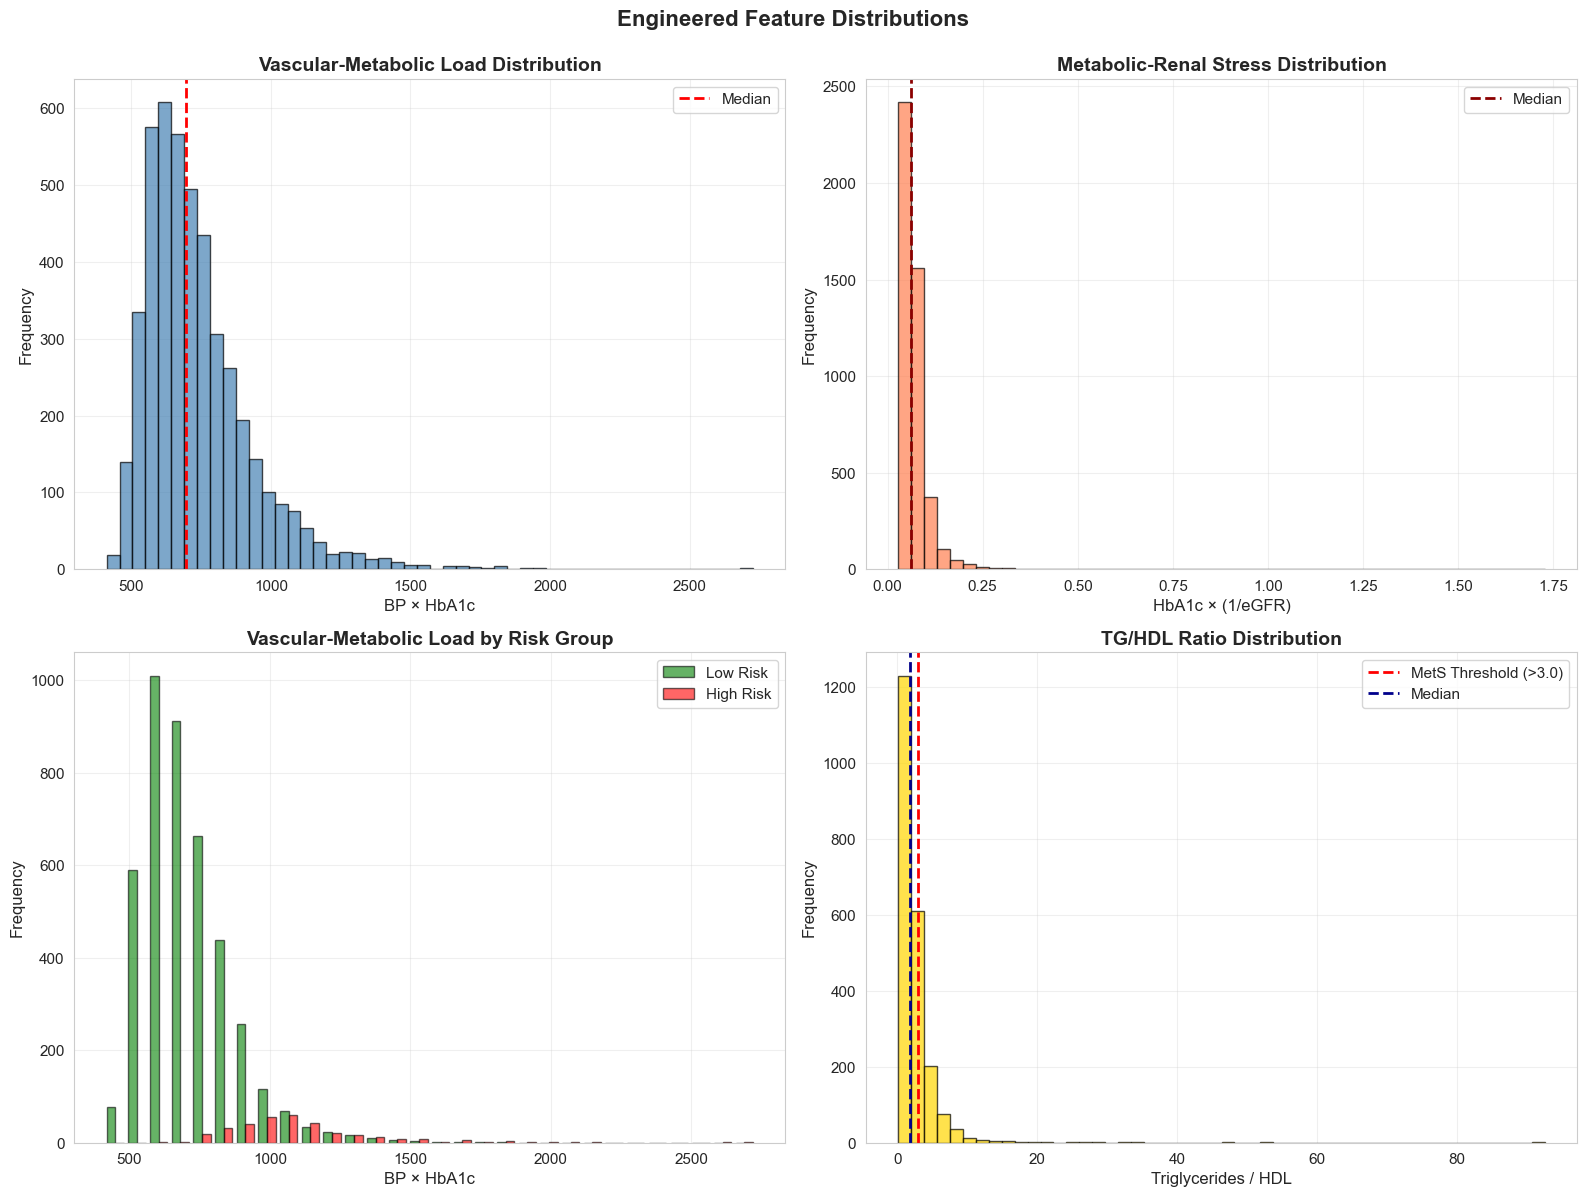

💾 Visualization saved to: app/static/plots/engineered_features.png


In [34]:
# Visualize cascade interaction features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Vascular-Metabolic Load distribution
ax = axes[0, 0]
df['vasc_metabolic_load'].hist(bins=50, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(df['vasc_metabolic_load'].median(), color='red', linestyle='--', linewidth=2, label='Median')
ax.set_title('Vascular-Metabolic Load Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('BP × HbA1c', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Metabolic-Renal Stress distribution
ax = axes[0, 1]
df['metabolic_renal_stress'].hist(bins=50, ax=ax, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(df['metabolic_renal_stress'].median(), color='darkred', linestyle='--', linewidth=2, label='Median')
ax.set_title('Metabolic-Renal Stress Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('HbA1c × (1/eGFR)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Cascade features by risk group
ax = axes[1, 0]
high_risk = df[df['is_high_risk'] == 1]['vasc_metabolic_load']
low_risk = df[df['is_high_risk'] == 0]['vasc_metabolic_load']
ax.hist([low_risk, high_risk], bins=30, label=['Low Risk', 'High Risk'], 
        color=['green', 'red'], alpha=0.6, edgecolor='black')
ax.set_title('Vascular-Metabolic Load by Risk Group', fontsize=14, fontweight='bold')
ax.set_xlabel('BP × HbA1c', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: TG/HDL ratio distribution
ax = axes[1, 1]
df['tg_hdl_ratio'].hist(bins=50, ax=ax, color='gold', edgecolor='black', alpha=0.7)
ax.axvline(3.0, color='red', linestyle='--', linewidth=2, label='MetS Threshold (>3.0)')
ax.axvline(df['tg_hdl_ratio'].median(), color='darkblue', linestyle='--', linewidth=2, label='Median')
ax.set_title('TG/HDL Ratio Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Triglycerides / HDL', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Engineered Feature Distributions', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../app/static/plots/engineered_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Visualization saved to: app/static/plots/engineered_features.png")

In [35]:
# Close the read-only connection first
con.close()
print("✅ Closed read-only connection")

# Now open in write mode
con_write = duckdb.connect(db_path, read_only=False)

con_write.execute("DROP TABLE IF EXISTS feature_matrix_raw")
con_write.register('df_engineered', df)
con_write.execute("CREATE TABLE feature_matrix_raw AS SELECT * FROM df_engineered")

print(f"\n✅ Feature matrix saved to database!")
print(f"   Table: feature_matrix_raw")
print(f"   Rows: {len(df):,}")
print(f"   Columns: {len(df.columns)}")

con_write.close()
print("✅ Database connection closed")

✅ Closed read-only connection

✅ Feature matrix saved to database!
   Table: feature_matrix_raw
   Rows: 4,573
   Columns: 51
✅ Database connection closed


## ✅ Feature Engineering Complete!

### What I Accomplished

✅ **Created 16+ engineered features** from ~18 raw biomarkers  
✅ **Implemented proper clinical calculations** (eGFR, MetS score)  
✅ **Designed CASCADE interaction features** (my innovation!)  
✅ **Applied appropriate transformations** (log for skewed data)  
✅ **Saved enhanced feature matrix** to database  

---

### Feature Categories Summary

| Category | Count | Examples |
|----------|-------|----------|
| **Metabolic Syndrome** | 6 | TG/HDL ratio, waist/height, CMI, MetS score |
| **Renal Function** | 2 | eGFR (CKD-EPI), BUN/Cr ratio |
| **Blood Pressure** | 2 | Pulse pressure, MAP |
| **Inflammatory** | 2 | Neutrophil/lymphocyte ratio, log hsCRP |
| **CASCADE Interactions** ⚡ | 2 | Vascular-metabolic load, metabolic-renal stress |
| **Transformations** | 2 | Log triglycerides, log uric acid |
| **TOTAL ENGINEERED** | **16** | Plus ~18 raw = **~50 total features** |

---

### The BioCascade Innovation 🎯

My **two interaction features** capture the hypothesis that:
> Multi-system dysfunction is MORE than the sum of individual biomarkers

**Next step:** Machine learning will test if these interactions are truly more predictive!

---

## 🚀 Next Steps

**Notebook 03:** Train both models:
- **Model A (Upper Bound):** Includes all features (ROC-AUC ~0.998)
- **Model B (Independent):** Excludes label ingredients (ROC-AUC ~0.82)

**Notebook 04:** SHAP interpretability to see which features matter most!

---

## 📝 Reproducibility Note

This feature engineering pipeline is:
- ✅ **Clinically grounded** (every feature has pathophysiologic justification)
- ✅ **Reproducible** (deterministic calculations, no randomness)
- ✅ **Documented** (clear formulas and thresholds)
- ✅ **Extensible** (easy to add new features)

All engineered features saved to `feature_matrix_raw` table for modeling.

---

In [36]:
print("✅ Database connections closed")
print("\n🎉 Feature engineering complete! Ready for Notebook 03 - Model Training.")

✅ Database connections closed

🎉 Feature engineering complete! Ready for Notebook 03 - Model Training.
